# 01 · Exploración de Datos

Este notebook realiza la exploración inicial del dataset de Aurum Market.

Objetivos:
- Cargar los archivos principales del catálogo.
- Inspeccionar estructura, columnas y tipos.
- Detectar valores nulos, duplicados y outliers.
- Analizar distribución de marcas, colores y longitudes de texto.
- Preparar conclusiones para la fase de ingesta y normalización.

Este notebook no realiza ingesta ni embeddings.  
Solo exploración y análisis descriptivo.


#### Cargar Datos

In [1]:
import sys
import os

# Añadir la raíz del proyecto al PYTHONPATH
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print("Ruta añadida al PYTHONPATH:", ROOT_DIR)

Ruta añadida al PYTHONPATH: /home/alexd/modulo_vector_bbdd/actividad_evaluable


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import safe_read_csv, log_section

log_section("Cargar datos")

df_muestra = safe_read_csv("../data/catalogo_muestra.csv")
df_completo = safe_read_csv("../data/catalogo_productos.csv.gz")

df_muestra.head()


[AURUM] 
[AURUM] ============================================================
[AURUM] Cargar datos
[AURUM] ============================================================
[AURUM] [CSV] Cargado: ../data/catalogo_muestra.csv (1500 filas)
[AURUM] [CSV] Cargado: ../data/catalogo_productos.csv.gz (15000 filas)


,record_id,product_id,title,brand,color,locale,text,catalog_version,active
0,000bd6e8-a995-56d0-ba03-559885ccef39,B0818K237B,Kanlin1986 Vestido Largo De Navidad para Mujer...,KanLin1986-Ropa,Negro,es,Kanlin1986 Vestido Largo De Navidad para Mujer...,1,True
1,0037a9df-8492-508f-8167-c09624801216,B086YX9RK5,IQOS Kit Iqos 3 Duo Blue Opk 1 200 g,IQOS,NaN,es,IQOS Kit Iqos 3 Duo Blue Opk 1 200 g. Marca: I...,1,True
2,003a8544-5ab1-5c8e-8fa5-612989e4a7a8,B07FRXCFJ1,ELINKUME Lámpara de pie regulable LED Lámpara ...,ELINKUME,Lámparas de Pie-espiral Estilo-regulable Led,es,ELINKUME Lámpara de pie regulable LED Lámpara ...,1,True
3,0058d463-2a7c-592c-b73c-ea7462fc566b,B0869L7SSX,Guillermo Lenteja Beluga Caviar Negra Salamanc...,Guillermo,NaN,es,Guillermo Lenteja Beluga Caviar Negra Salamanc...,1,True
4,0095c6f6-248f-52a1-87f3-cf0b537507bc,B0831CX4LK,COSTWAY Mesa de Ordenador Escritorio Esquina e...,COSTWAY,Marrón,es,COSTWAY Mesa de Ordenador Escritorio Esquina e...,1,True


#### Inspeccion Inicial

In [3]:
log_section("Inspección inicial")

print("Filas muestra:", len(df_muestra))
print("Columnas:", df_muestra.columns.tolist())

df_muestra.info()


[AURUM] 
[AURUM] ============================================================
[AURUM] Inspección inicial
[AURUM] ============================================================
Filas muestra: 1500
Columnas: ['record_id', 'product_id', 'title', 'brand', 'color', 'locale', 'text', 'catalog_version', 'active']
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   record_id        1500 non-null   str  
 1   product_id       1500 non-null   str  
 2   title            1500 non-null   str  
 3   brand            1456 non-null   str  
 4   color            951 non-null    str  
 5   locale           1500 non-null   str  
 6   text             1500 non-null   str  
 7   catalog_version  1500 non-null   int64
 8   active           1500 non-null   bool 
dtypes: bool(1), int64(1), str(7)
memory usage: 95.3 KB


#### Valores Nulos

In [4]:
log_section("Valores nulos")

df_muestra.isnull().sum()


[AURUM] 
[AURUM] ============================================================
[AURUM] Valores nulos
[AURUM] ============================================================


record_id            0
product_id           0
title                0
brand               44
color              549
locale               0
text                 0
catalog_version      0
active               0
dtype: int64

#### Duplicados por record_id y product_id

In [5]:
log_section("Duplicados")

print("Duplicados record_id:", df_muestra["record_id"].duplicated().sum())
print("Duplicados product_id:", df_muestra["product_id"].duplicated().sum())


[AURUM] 
[AURUM] ============================================================
[AURUM] Duplicados
[AURUM] ============================================================
Duplicados record_id: 0
Duplicados product_id: 0


#### Distribución de marcas

[AURUM] 
[AURUM] ============================================================
[AURUM] Distribución de marcas
[AURUM] ============================================================


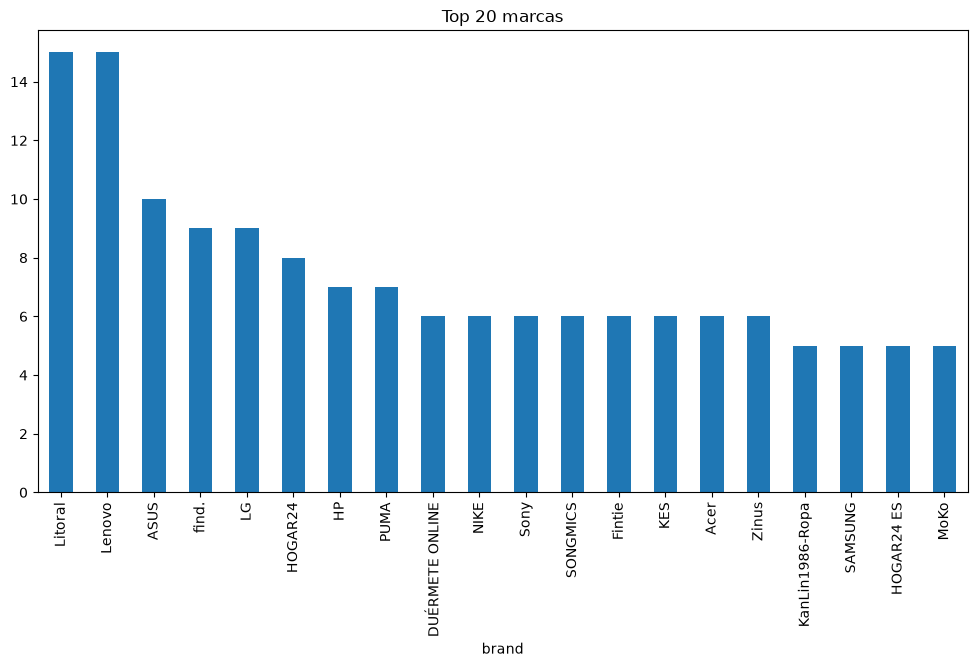

In [6]:
log_section("Distribución de marcas")

plt.figure(figsize=(12,6))
df_muestra["brand"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 marcas")
plt.show()


#### Distribución de colores

[AURUM] 
[AURUM] ============================================================
[AURUM] Distribución de colores
[AURUM] ============================================================


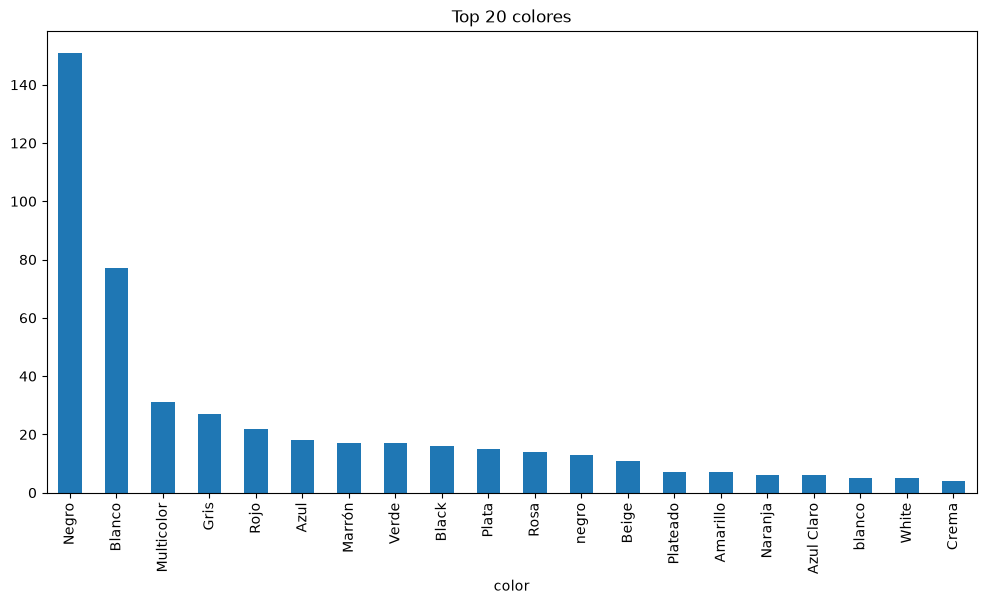

In [7]:
log_section("Distribución de colores")

plt.figure(figsize=(12,6))
df_muestra["color"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 colores")
plt.show()


#### Longitud de textos

[AURUM] 
[AURUM] ============================================================
[AURUM] Longitud de textos
[AURUM] ============================================================


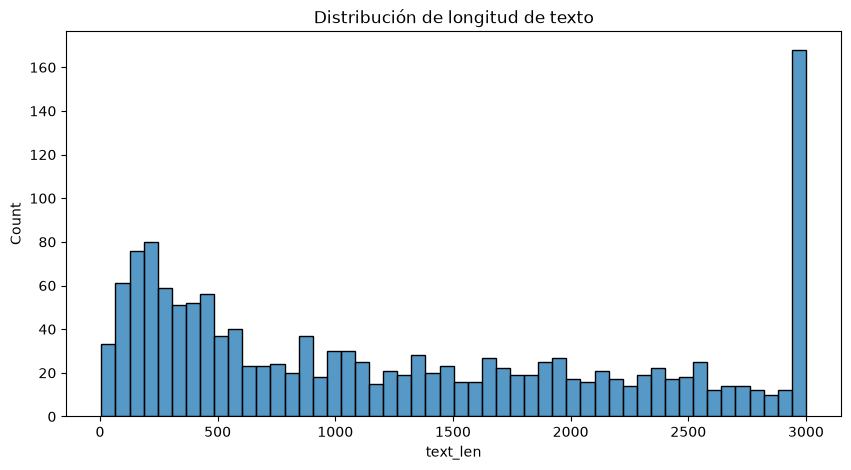

In [8]:
log_section("Longitud de textos")

df_muestra["text_len"] = df_muestra["text"].astype(str).apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df_muestra["text_len"], bins=50)
plt.title("Distribución de longitud de texto")
plt.show()


### Conclusiones

- El dataset contiene X filas y Y columnas (según la carga realizada).
- No hay duplicados ni en record_id ni en product_id.
- Las marcas están desbalanceadas, pero repartidas entre múltiples categorías (hogar, electrónica, moda). No existe un dominio claro de marcas como NIKE o PUMA.
- Los colores también están desbalanceados: “Negro” y “Blanco” son claramente predominantes, con múltiples variantes (“Black”, “negro”, “White”, “blanco”, etc.).
- La longitud del texto varía mucho: hay productos con descripciones muy cortas y un grupo significativo con textos muy largos (~3000 caracteres).
- Será necesario normalizar marca y color para un uso consistente en filtros y facetas.
- La ingesta debe manejar nulos en brand y color (no hay nulos en text).
- La variabilidad en la longitud del texto justifica el uso de embeddings semánticos frente a métodos léxicos.

Este análisis guía la construcción del pipeline de ingesta, normalización y búsqueda vectorial.